In [3]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize

import healpy as hp

In [4]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

plt.rcParams['image.cmap'] = 'jet'

In [5]:
target_dir = '/Volumes/Samsung T5/tmp/dr9m-sep26-2020'
data_dir = '/Volumes/Samsung T5/tmp/dr9_tests'

maskbits = [1, 5, 6, 7, 8, 9, 11, 12, 13]
min_nobs = 1

target_class = 'LRG'
target_columns = ['RA', 'DEC',
        'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
        'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2',
        'NOBS_G', 'NOBS_R', 'NOBS_Z',
        'MORPHTYPE', 'EBV', 'MASKBITS', 'PHOTSYS']

target_path_list = glob.glob(os.path.join(target_dir, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
print(len(target_path_list))

target_bits = {'LRG':0, 'ELG':1, 'QSO':2, 'BGS_ANY':60}
target_bit = target_bits[target_class]

37


--------
# North

In [6]:
field = 'north'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [7]:
cat = Table.read(os.path.join(data_dir, '{}_dr9m_{}.fits'.format(target_class, field)))

mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

0.029908181901711434
2407213
2407213


/Users/rongpu/miniconda3/lib/python3.7/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


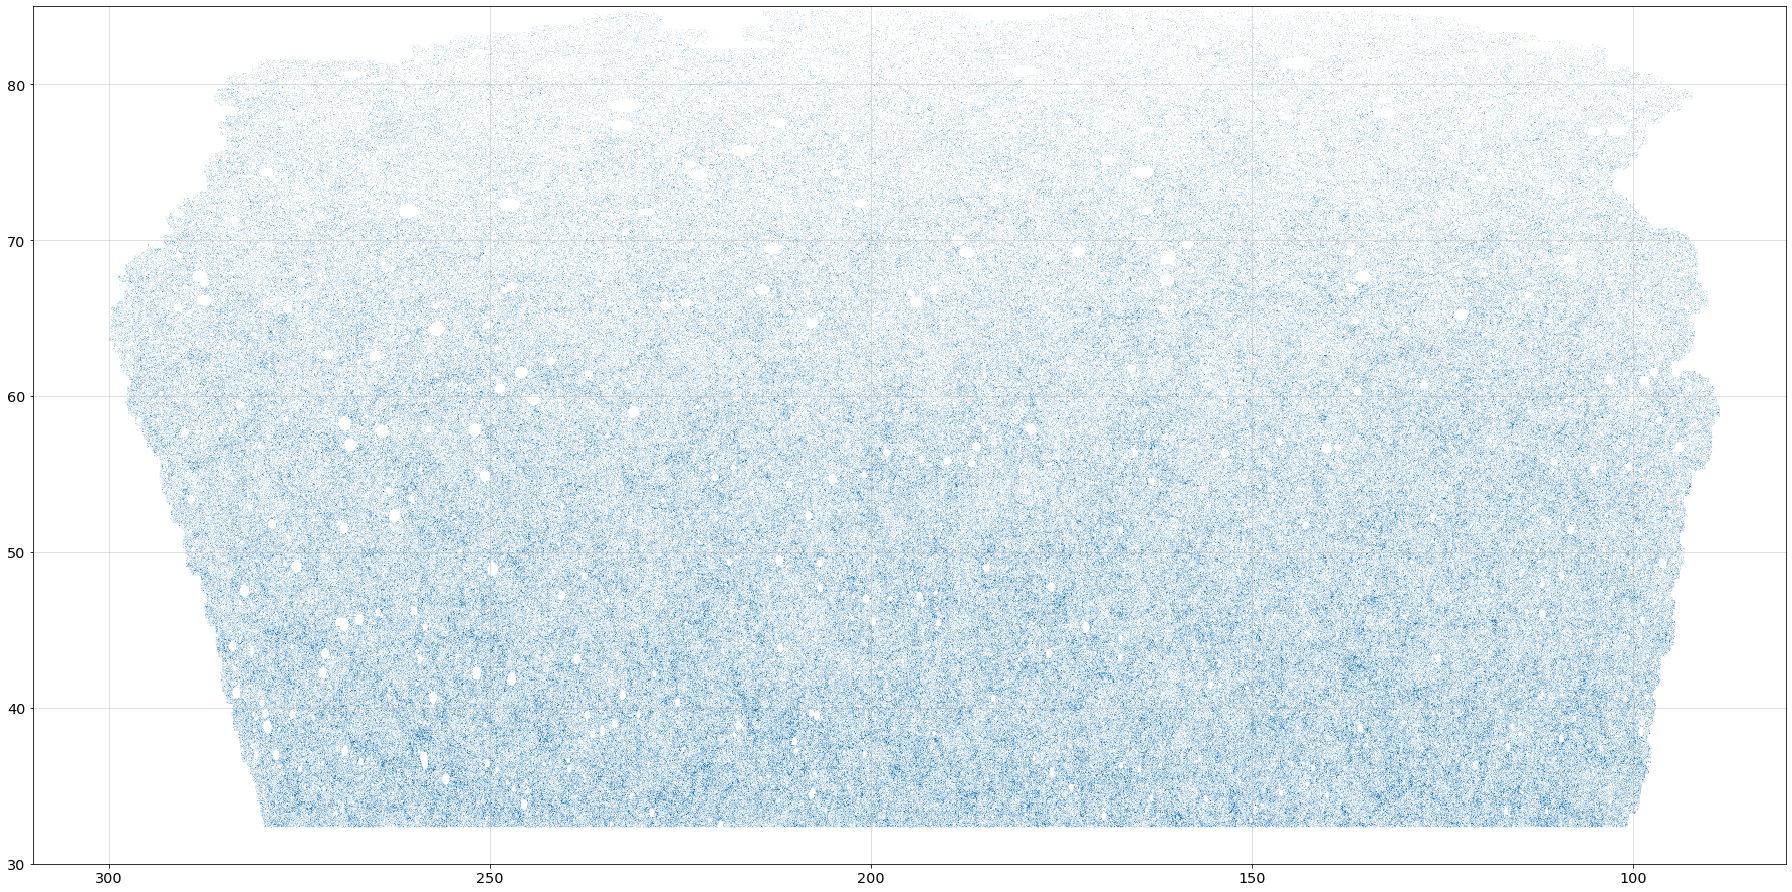

In [8]:
norm = ImageNormalize(vmin=0., vmax=12)
fig = plt.figure(figsize=(25, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'], cat['DEC'], color='C0', norm=norm)
ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/tmp_{}_{}_dr9.png'.format(target_class, field))
plt.show()

In [15]:
nside = 64

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

# Assign objects to healpix pixels
pix = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
pix_unique, pix_count = np.unique(pix, return_counts=True)
m0 = np.zeros(npix, dtype=int)
m0[pix_unique] = pix_count
hp_mask = m0>0

#############################################################################

hp_table = Table()
hp_table['hp_idx'] = np.arange(npix)
hp_table['ra'], hp_table['dec'] = hp.pixelfunc.pix2ang(nside, hp_table['hp_idx'], nest=False, lonlat=True)
hp_table['count'] = m0
hp_table = hp_table[hp_mask]
hp_table.write(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))

Healpix size = 0.83929 sq deg


In [18]:
nside = 128

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

# Assign objects to healpix pixels
pix = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
pix_unique, pix_count = np.unique(pix, return_counts=True)
m0 = np.zeros(npix, dtype=int)
m0[pix_unique] = pix_count
hp_mask = m0>0

#############################################################################

hp_table = Table()
hp_table['hp_idx'] = np.arange(npix)
hp_table['ra'], hp_table['dec'] = hp.pixelfunc.pix2ang(nside, hp_table['hp_idx'], nest=False, lonlat=True)
hp_table['count'] = m0
hp_table = hp_table[hp_mask]
hp_table.write(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))

Healpix size = 0.20982 sq deg


In [19]:
nside = 256

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

# Assign objects to healpix pixels
pix = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
pix_unique, pix_count = np.unique(pix, return_counts=True)
m0 = np.zeros(npix, dtype=int)
m0[pix_unique] = pix_count
hp_mask = m0>0

#############################################################################

hp_table = Table()
hp_table['hp_idx'] = np.arange(npix)
hp_table['ra'], hp_table['dec'] = hp.pixelfunc.pix2ang(nside, hp_table['hp_idx'], nest=False, lonlat=True)
hp_table['count'] = m0
hp_table = hp_table[hp_mask]
hp_table.write(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))

Healpix size = 0.05246 sq deg


--------
# South

In [20]:
field = 'south'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [21]:
cat = Table.read(os.path.join(data_dir, '{}_dr9m_{}.fits'.format(target_class, field)))

mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

0.014955862485810816
3888510
3888510


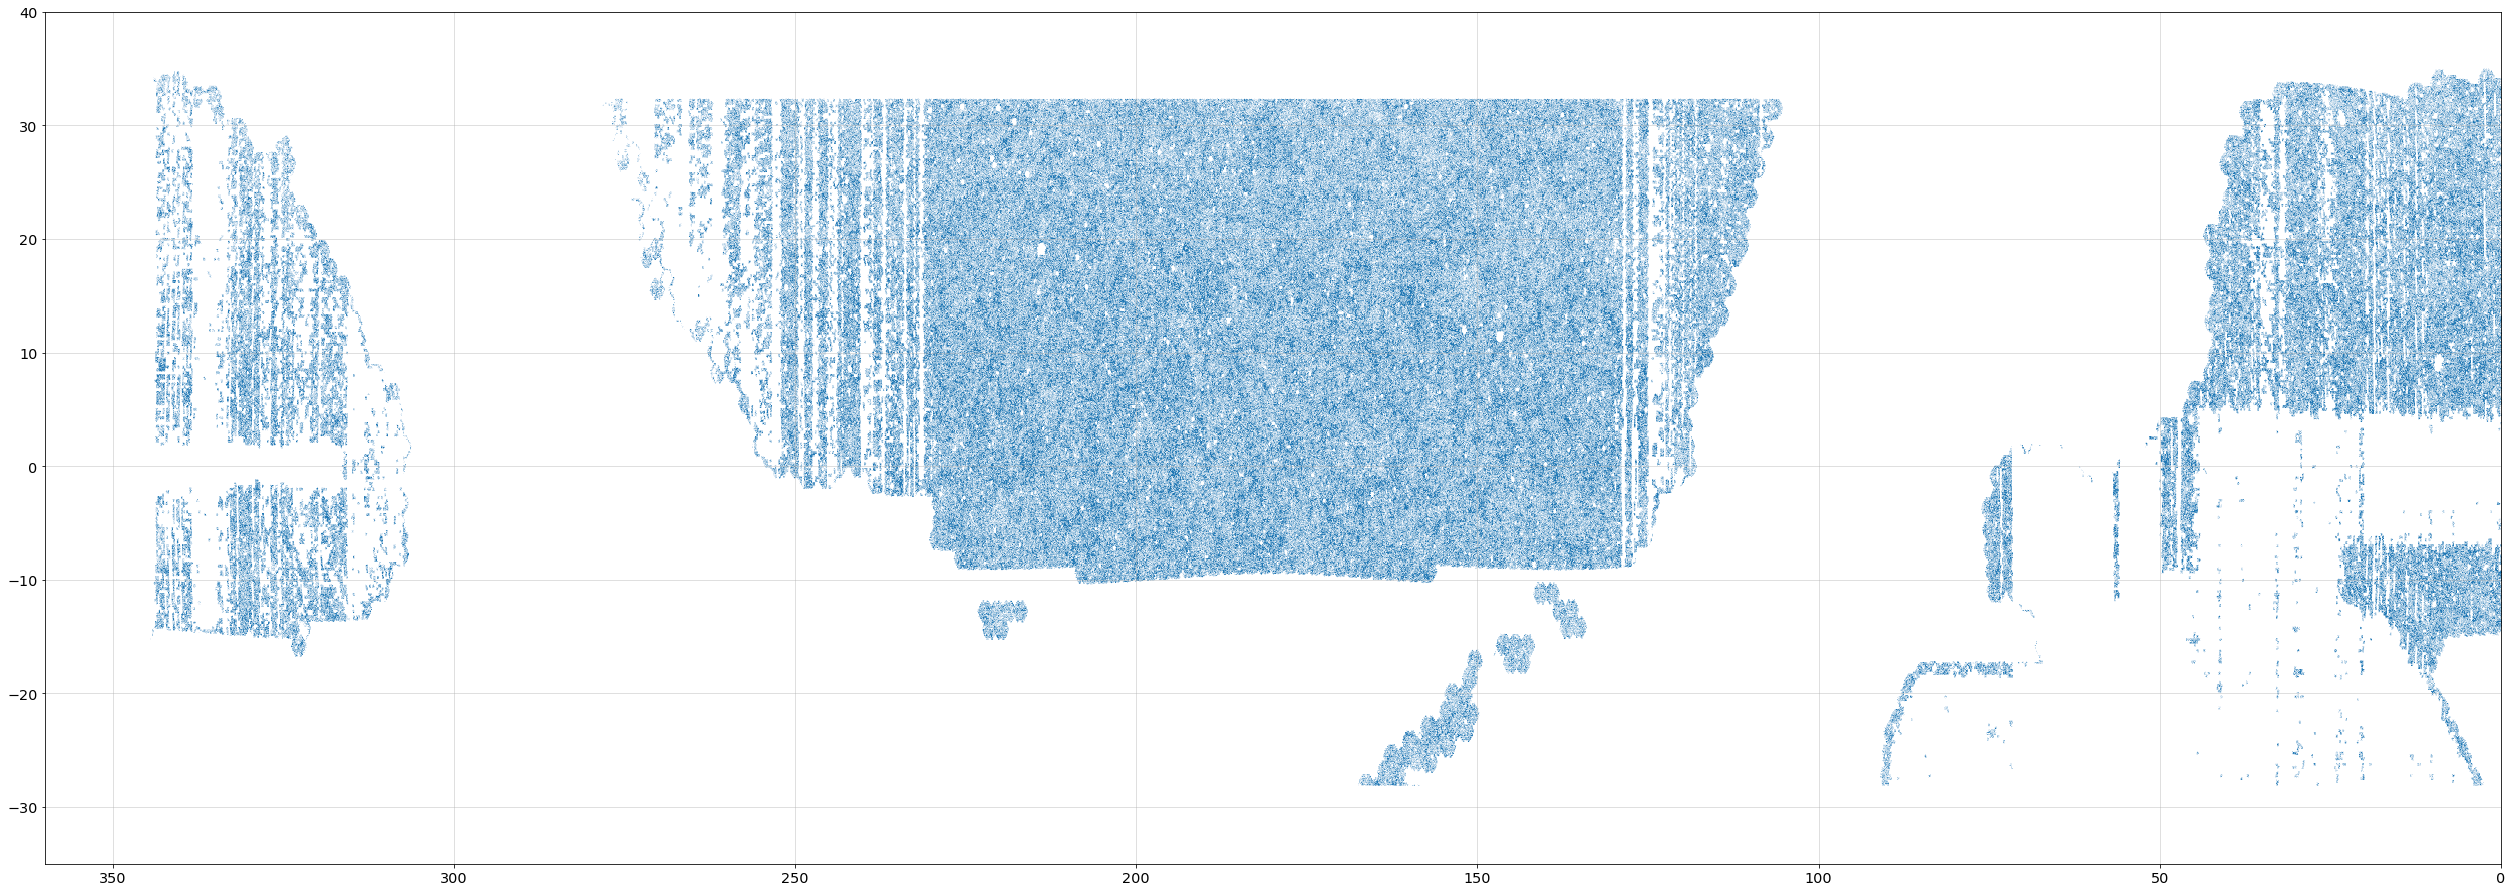

In [32]:
norm = ImageNormalize(vmin=0., vmax=15)
fig = plt.figure(figsize=(35, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'], cat['DEC'], color='C0', norm=norm)
ax.axis([360, 0, -35, 40])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/tmp_{}_{}_dr9.png'.format(target_class, field))
plt.show()

In [28]:
nside = 64

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

# Assign objects to healpix pixels
pix = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
pix_unique, pix_count = np.unique(pix, return_counts=True)
m0 = np.zeros(npix, dtype=int)
m0[pix_unique] = pix_count
hp_mask = m0>0

#############################################################################

hp_table = Table()
hp_table['hp_idx'] = np.arange(npix)
hp_table['ra'], hp_table['dec'] = hp.pixelfunc.pix2ang(nside, hp_table['hp_idx'], nest=False, lonlat=True)
hp_table['count'] = m0
hp_table = hp_table[hp_mask]
hp_table.write(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))

Healpix size = 0.83929 sq deg


In [29]:
nside = 128

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

# Assign objects to healpix pixels
pix = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
pix_unique, pix_count = np.unique(pix, return_counts=True)
m0 = np.zeros(npix, dtype=int)
m0[pix_unique] = pix_count
hp_mask = m0>0

#############################################################################

hp_table = Table()
hp_table['hp_idx'] = np.arange(npix)
hp_table['ra'], hp_table['dec'] = hp.pixelfunc.pix2ang(nside, hp_table['hp_idx'], nest=False, lonlat=True)
hp_table['count'] = m0
hp_table = hp_table[hp_mask]
hp_table.write(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))

Healpix size = 0.20982 sq deg


In [30]:
nside = 256

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

# Assign objects to healpix pixels
pix = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
pix_unique, pix_count = np.unique(pix, return_counts=True)
m0 = np.zeros(npix, dtype=int)
m0[pix_unique] = pix_count
hp_mask = m0>0

#############################################################################

hp_table = Table()
hp_table['hp_idx'] = np.arange(npix)
hp_table['ra'], hp_table['dec'] = hp.pixelfunc.pix2ang(nside, hp_table['hp_idx'], nest=False, lonlat=True)
hp_table['count'] = m0
hp_table = hp_table[hp_mask]
hp_table.write(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))

Healpix size = 0.05246 sq deg
